In [4]:
# procesamiento de datos Machine learnig
# Objetivo aplicar las principales tecnicas de procesamiento de datos para preparar un DataSet antes de entrenar un 
#modelo de uml 
# problema se desea construir un modelo capaz de predecir si un pasajero sobrevivio o no al hundimiento al titanic 

In [2]:
# Importar librerías
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
pip install Kagglehub

  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.30-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.2-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.30-py3-none-any.whl (231 kB)

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [Kagglehub]
   ---------------------------------------- 2/2 [Kagglehub]

Note: you may need to restart the kernel to use updated packages.


In [15]:
# en caso de no instalar la libreria comando : pip install scikit-learn
!pip install kagglehub

In [3]:
import kagglehub

In [5]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

100%|█████████████████████████████████████████████████████████████████████████████| 22.0k/22.0k [00:00<00:00, 59.0kB/s]

Extracting files...


In [6]:
print("Ruta del dataset:",path)

Ruta del dataset: C:\Users\twdcr\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [7]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

In [8]:
dfTitanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
dfTitanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## parte 1 comprension del problema
Determinar si sobrevivieron al hundimiento del Titanic, con base en la informacion 
obtenida
Suvirved
O no sobrevivio
1 si sobrevivio

In [10]:
#revisar cuantos sobrevivieron.
dfTitanic ["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

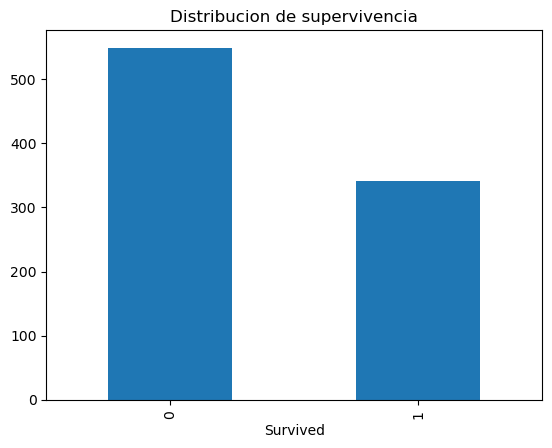

In [12]:
#Graficamos
dfTitanic["Survived"].value_counts().plot(
    kind="bar"
)
plt.title("Distribucion de supervivencia")
plt.show()

In [13]:
## parte 2 . Exploracion Inicial
dfTitanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
# Hipótesis inicial
dfTitanic.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [16]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [18]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## parte 3 . Correlacion e Hipotesis 
creamos una matriz de correlacion para identificar la realacion lineal
entre las variables.No identifica la importancia real de variables en el modelo.

In [21]:
variables_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

In [22]:
corr = dfTitanic[variables_numericas].corr()

In [23]:
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


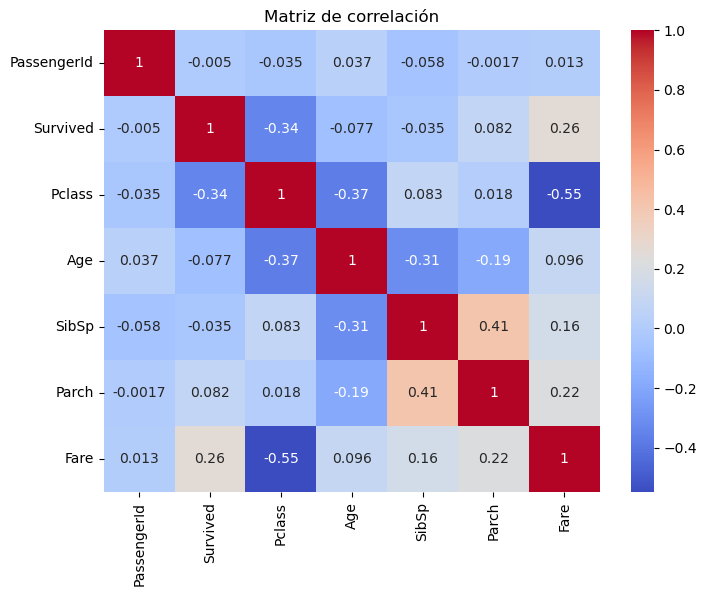

In [26]:
# Calcular la matriz de correlación
corr = dfTitanic.corr(numeric_only=True)

# Graficar
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de correlación")
plt.show()

## Parte 4 .Seleccion de variables Predictoras y Variables Objetivo
x - Variables que utilizara el modelo 
y - Variables que queremos predecir 

In [27]:
columnas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

In [29]:
# Definimos X y y
X = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [30]:
print(X.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [31]:
print(y.name)

Survived


## parte 5. Tratamiento de los valores
para simplificar un poco el proceso,realizaremos la imputacion de los datos antes de la separacion TRAINT/TEST

In [33]:
#Revisamos las variables predictorias 
X.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [37]:
print(X["Age"].dtype)

object


In [39]:
X.loc[:, "Age"] = pd.to_numeric(X["Age"], errors="coerce")
X.loc[:, "Age"] = X["Age"].fillna(X["Age"].median())

In [40]:
X.loc[:, "Embarked"] = X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

In [41]:
X.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [42]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## parte 6. Escalado de los datos
Los algoritmos no tienen texto. Se deben de convertir en varibles categoricas a variables numericas

In [44]:
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [45]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


# parte 7.Particiamos los datos 
No debemos entrenar y evaluar utilizando los mismos datos.
La recomendacion es :
Entrenamiento 80% Prueblas 20%

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [49]:
print("Entrenamiento:", X_train.shape)

Entrenamiento: (712, 8)


In [48]:
print("Prueba:",y_test.shape)

Prueba: (179,)


#PARTE 8 . Escalado De Variables 
Las  variables numericas tienen valores distintos. El escalado evita que una variable domine una tras otra.

In [51]:
columnas_numericas = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

In [52]:
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,712.000000,712.000000,712.000000,712.000000
mean,29.204129,32.586276,0.553371,0.379213
std,13.007971,51.969529,1.176404,0.791669
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.925000,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,30.500000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [53]:
scaler =StandardScaler()
X_train[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)
X_test[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)

In [54]:
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02
mean,1.746418e-17,5.363999e-17,1.746418e-17,2.245395e-17
std,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00
min,-2.214363e+00,-6.274674e-01,-4.707224e-01,-4.793416e-01
25%,-5.542135e-01,-4.748670e-01,-4.707224e-01,-4.793416e-01
50%,-9.263364e-02,-3.491435e-01,-4.707224e-01,-4.793416e-01
75%,4.458762e-01,-4.017244e-02,3.799232e-01,-4.793416e-01
max,3.907725e+00,9.237724e+00,6.334442e+00,7.104908e+00


# PARTE 9. Entrenamiento de los datos 
Usaremos en el arbol de decision para clasificar registros 

In [56]:
modelo = DecisionTreeClassifier (
    max_depth = 4,
    random_state =42
)

In [58]:
modelo.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=4, random_state=42)

# Parte 10. Evaluamos el modelo 
Realizamos predicciones para evaluar el modelo

In [59]:
predicciones = modelo.predict(
                        X_test
)

In [60]:
pd.DataFrame({
    "Real": y_test,
    "Prediccion": predicciones
}).head(30)


,Real,Prediccion
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


# PARTE 11. Evaluacion del modelo 
El accury determinar el porcentaje de predicciones correctas realizadas por el modelo 

In [62]:
accuracy =accuracy_score(
    y_test,
    predicciones
)

In [64]:
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7989


## Interpretación del Accuracy

| Accuracy | Interpretación |
|----------|----------------|
| < 50% | Muy bajo |
| 50% | Adivina |
| 60% - 70% | Aceptable / Básico |
| 70% - 80% | Bueno |
| 80% - 90% | Muy bueno |
| > 90% | Excelente (revisar posible sobreajuste) |

In [ ]:
# PARTE 12 . Importancia de las variables 
Analizar las Variables mas relevantes para el algoritmo,al realizar las predicciones 

In [68]:
importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo.feature_importances_
})

In [71]:
importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

In [72]:
importancias

,Variable,Importancia
5,Sex_male,0.579608
0,Pclass,0.200498
4,Fare,0.081064
1,Age,0.078872
2,SibSp,0.046059
7,Embarked_S,0.013900
3,Parch,0.000000
6,Embarked_Q,0.000000
